# Image Segmentation with UNet++ and EfficientNet-B0
## Fixed version with proper metrics and class imbalance handling

## Step 1: Install Dependencies and Import Libraries

In [1]:
!pip install -q segmentation-models-pytorch albumentations

import os
import cv2
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

print("✅ Libraries imported successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.3 MB/s eta 0:00:0000:01


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

✅ Libraries imported successfully


## Step 2: Configuration and Setup

In [22]:
# Paths
DATA_ROOT = "/kaggle/input/datalombaaraits/dataset/dataset"
TRAIN_IMG_DIR  = os.path.join(DATA_ROOT, "train/images")
TRAIN_MASK_DIR = os.path.join(DATA_ROOT, "train/mask")
TEST_IMG_DIR   = os.path.join(DATA_ROOT, "test/images")

print("Train images:", len(os.listdir(TRAIN_IMG_DIR)))
print("Train masks :", len(os.listdir(TRAIN_MASK_DIR)))
print("Test images :", len(os.listdir(TEST_IMG_DIR)))

# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# Hyperparameters
IMG_SIZE = 896
BATCH_SIZE = 2
EPOCHS = 70
LR = 3e-4  # Slightly higher learning rate
THRESHOLD = 0.5  # Threshold for binary prediction

print("\n✅ Configuration set")

Train images: 498
Train masks : 498
Test images : 295
Device: cuda

✅ Configuration set


## Step 3: Utility Functions - FIXED VERSION

In [4]:
# Mask name matching
MASK_PREFIX = "mask_"

def image_to_mask_name(image_name: str) -> str:
    """Convert image filename to corresponding mask filename"""
    idx = image_name.split("_")[-1]
    idx = os.path.splitext(idx)[0]
    return f"{MASK_PREFIX}{idx}.png"

# Read functions - CRITICAL FIX HERE
def read_rgb(path):
    """Read RGB image"""
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def read_mask(path):
    """Read mask - FIXED to return float32 values 0.0 or 1.0"""
    m = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise FileNotFoundError(path)
    # CRITICAL: Return 0.0 or 1.0 as float32, not 0 or 255
    return (m > 127).astype(np.float32)

# Get file lists
train_imgs = sorted([f for f in os.listdir(TRAIN_IMG_DIR) if not f.startswith(".")])
test_imgs  = sorted([f for f in os.listdir(TEST_IMG_DIR) if not f.startswith(".")])

# Check for missing masks
missing = []
for fn in train_imgs:
    mp = os.path.join(TRAIN_MASK_DIR, image_to_mask_name(fn))
    if not os.path.exists(mp):
        missing.append(fn)

print("Train images:", len(train_imgs))
print("Test images :", len(test_imgs))
print("Missing mask:", len(missing))
print("\n✅ Utility functions defined")

Train images: 498
Test images : 295
Missing mask: 0

✅ Utility functions defined


## Step 4: Data Augmentation

In [5]:
# Training augmentations
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussianBlur(p=0.2),
    A.Resize(IMG_SIZE, IMG_SIZE),
    ToTensorV2(),
])

# Validation augmentations (no random transforms)
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    ToTensorV2(),
])

print("✅ Augmentation pipelines created")

✅ Augmentation pipelines created


## Step 5: Dataset Class - FIXED VERSION

In [6]:
class SegDataset(Dataset):
    """Segmentation Dataset - FIXED to return proper mask shape"""
    
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = sorted([f for f in os.listdir(img_dir) if not f.startswith(".")])
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        mask_name = image_to_mask_name(img_name)
        
        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)
        
        # Read image and mask
        img = read_rgb(img_path)
        mask = read_mask(mask_path)  # Now returns float32 [0.0, 1.0]
        
        # Apply transformations
        if self.transform:
            transformed = self.transform(image=img, mask=mask)
            img = transformed['image']
            mask = transformed['mask']
        
        # CRITICAL FIX: Ensure image is float32 and normalized to [0, 1]
        if img.dtype == torch.uint8:
            img = img.float() / 255.0
        
        # CRITICAL FIX: Add channel dimension to mask
        # After transform: img is [3, H, W], mask is [H, W]
        # We need mask to be [1, H, W] to match model output
        if isinstance(mask, torch.Tensor):
            if mask.dim() == 2:
                mask = mask.unsqueeze(0)  # [H, W] -> [1, H, W]
        else:
            mask = torch.from_numpy(mask).unsqueeze(0)
        
        mask = mask.float()  # Ensure float type
        
        return img, mask

print("✅ Dataset class defined")

✅ Dataset class defined


## Step 6: Visualize Data (IMPORTANT - Check if masks are correct!)

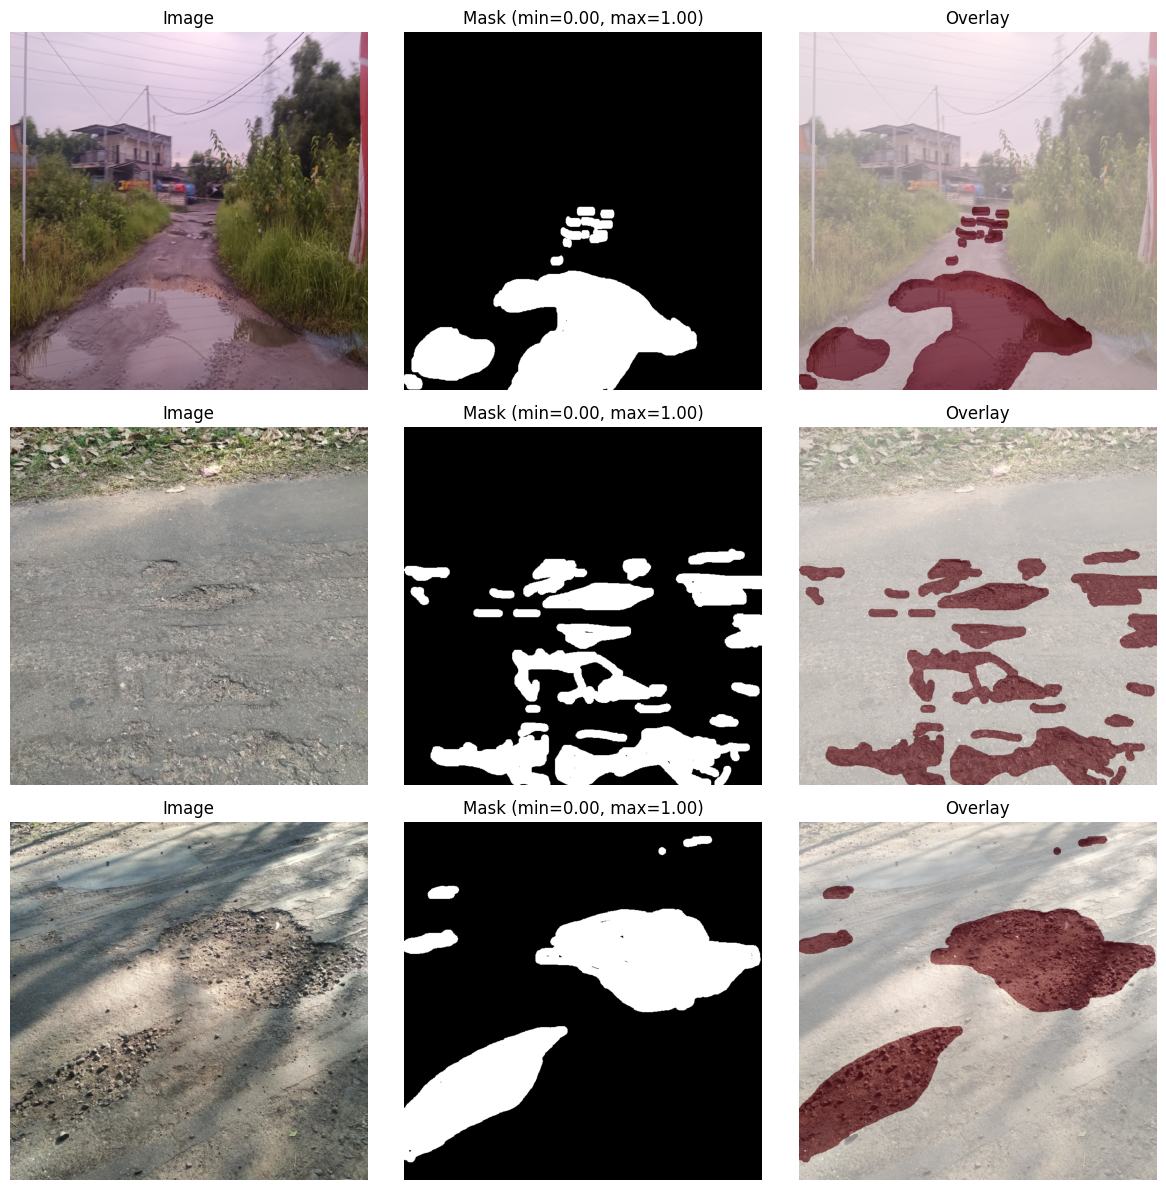


Mask statistics for 3 samples:
Sample 0: 15.14% foreground pixels
Sample 1: 19.83% foreground pixels
Sample 2: 20.04% foreground pixels

⚠️ CHECK: Masks should show clear white regions on black background
⚠️ CHECK: Overlay should show red regions over the objects to segment


In [7]:
def visualize_samples(dataset, n=3):
    """Visualize sample images and masks to verify data loading"""
    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    
    for i in range(n):
        img, mask = dataset[i]
        
        # Convert tensor to numpy
        img_np = img.permute(1, 2, 0).numpy()
        mask_np = mask.squeeze().numpy()  # Remove channel dimension for visualization
        
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title('Image')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mask_np, cmap='gray', vmin=0, vmax=1)
        axes[i, 1].set_title(f'Mask (min={mask_np.min():.2f}, max={mask_np.max():.2f})')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(img_np)
        axes[i, 2].imshow(mask_np, cmap='Reds', alpha=0.5, vmin=0, vmax=1)
        axes[i, 2].set_title('Overlay')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nMask statistics for {n} samples:")
    for i in range(n):
        _, mask = dataset[i]
        mask_np = mask.numpy()
        positive_pixels = (mask_np > 0.5).sum()
        total_pixels = mask_np.size
        percent = (positive_pixels / total_pixels) * 100
        print(f"Sample {i}: {percent:.2f}% foreground pixels")

# Create dataset and visualize
temp_dataset = SegDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, transform=val_transform)
visualize_samples(temp_dataset, n=3)

print("\n⚠️ CHECK: Masks should show clear white regions on black background")
print("⚠️ CHECK: Overlay should show red regions over the objects to segment")

## Step 7: Create Data Loaders

In [21]:
# Create datasets
train_dataset = SegDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, transform=train_transform)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print(f"Training samples: {len(train_dataset)}")
print(f"Training batches: {len(train_loader)}")

# Test the data loader
test_batch = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"Images: {test_batch[0].shape}")
print(f"Masks:  {test_batch[1].shape}")
print("\n✅ Data loaders created successfully")

Training samples: 498
Training batches: 249

Batch shapes:
Images: torch.Size([2, 3, 768, 768])
Masks:  torch.Size([2, 1, 768, 768])

✅ Data loaders created successfully


## Step 8: Define Model

In [23]:
# Create Deeplab model with EfficientNet-B0 encoder
model = smp.DeepLabV3Plus(
    encoder_name="efficientnet-b4",  # B2 > B0 for 768x768
    encoder_weights="imagenet",
    encoder_depth=5,
    decoder_channels=256,
    in_channels=3,
    classes=1,
    activation=None, 
)

model = model.to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("\n✅ Model created and moved to", DEVICE)

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Total parameters: 18,616,217
Trainable parameters: 18,616,217

✅ Model created and moved to cuda


## Step 9: Loss Functions - WITH FOCAL LOSS FOR CLASS IMBALANCE

In [24]:
class DiceLoss(nn.Module):
    """Dice Loss for segmentation"""
    
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, inputs, targets):
        inputs = torch.sigmoid(inputs)
        
        inputs_flat = inputs.view(-1)
        targets_flat = targets.view(-1)
        
        intersection = (inputs_flat * targets_flat).sum()
        dice = (2. * intersection + self.smooth) / (
            inputs_flat.sum() + targets_flat.sum() + self.smooth
        )
        
        return 1 - dice

# Combined loss function
pos_weight = torch.tensor([15.0]).to(DEVICE)
bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
dice_loss = DiceLoss()

def loss_fn(pred, target):
    return bce(pred, target) + dice_loss(pred, target)

print("✅ Loss functions defined (Dice Loss)")

✅ Loss functions defined (Dice Loss)


## Step 10: Metrics Functions

In [25]:
def calculate_iou(pred, target, threshold=0.5, smooth=1e-6):
    """Calculate IoU (Intersection over Union)"""
    pred = (torch.sigmoid(pred) > threshold).float()
    target = target.float()
    
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    
    iou = (intersection + smooth) / (union + smooth)
    return iou.item()

def calculate_dice(pred, target, threshold=0.5, smooth=1e-6):
    """Calculate Dice Score"""
    pred = (torch.sigmoid(pred) > threshold).float()
    target = target.float()
    
    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    
    return dice.item()

def calculate_pixel_accuracy(pred, target, threshold=0.5):
    """Calculate pixel-wise accuracy"""
    pred = (torch.sigmoid(pred) > threshold).float()
    target = target.float()
    
    correct = (pred == target).float().sum()
    total = target.numel()
    
    return (correct / total).item()

def calculate_precision_recall(pred, target, threshold=0.5, smooth=1e-6):
    """Calculate Precision and Recall"""
    pred = (torch.sigmoid(pred) > threshold).float()
    target = target.float()
    
    true_positive = (pred * target).sum()
    false_positive = (pred * (1 - target)).sum()
    false_negative = ((1 - pred) * target).sum()
    
    precision = (true_positive + smooth) / (true_positive + false_positive + smooth)
    recall = (true_positive + smooth) / (true_positive + false_negative + smooth)
    
    return precision.item(), recall.item()

print("✅ Metric functions defined")

✅ Metric functions defined


## Step 11: Optimizer and Scheduler

In [26]:
# Optimizer
LR = 3e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# Learning rate scheduler
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, 
#     mode='min', 
#     factor=0.75, 
#     patience=3
# )

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,
    T_mult=2,
    eta_min=1e-6
)

print("✅ Optimizer and scheduler created")

✅ Optimizer and scheduler created


## Step 12: Training Loop - WITH FULL METRICS

In [27]:
# Training history
history = {
    'train_loss': [],
    'train_iou': [],
    'train_dice': [],
    'train_accuracy': [],
    'train_precision': [],
    'train_recall': []


best_loss = float('inf')
best_iou = 0.0

print("Starting training...\n")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    epoch_iou = 0
    epoch_dice = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for imgs, masks in pbar:
        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE)
        
        # Forward
        preds = model(imgs)
        loss = loss_fn(preds, masks)
        
        # Metrics
        iou = calculate_iou(preds, masks, threshold=0.5)
        dice = calculate_dice(preds, masks, threshold=0.5)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_iou += iou
        epoch_dice += dice
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'iou': f'{iou:.4f}',
            'dice': f'{dice:.4f}'
        })
    
    # Epoch summary
    n = len(train_loader)
    avg_loss = epoch_loss / n
    avg_iou = epoch_iou / n
    avg_dice = epoch_dice / n
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(avg_loss)
    history['train_iou'].append(avg_iou)
    history['train_dice'].append(avg_dice)
    
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Loss: {avg_loss:.4f} | IoU: {avg_iou:.4f} | Dice: {avg_dice:.4f} | LR: {current_lr:.2e}")
    
    # Step scheduler
    scheduler.step()
    
    # Save best model
    if avg_iou > best_iou:
        best_iou = avg_iou
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'iou': avg_iou,
            'dice': avg_dice,
            'loss': avg_loss,
        }, "best_deeplabv3plus.pth")
        print("🔥 BEST MODEL SAVED")
    else:
        patience_counter += 1
        print(f"No improvement for {patience_counter} epochs")
    
    print("-" * 70)

print(f"\n✅ Training complete! Best IoU: {best_iou:.4f}")

Starting training...



Epoch 1/70: 100%|██████████| 249/249 [02:21<00:00,  1.75it/s, loss=1.1514, iou=0.2223, dice=0.3637]



Epoch 1/70
Loss: 1.9296 | IoU: 0.3539 | Dice: 0.4978 | LR: 3.00e-04
🔥 BEST MODEL SAVED
----------------------------------------------------------------------


Epoch 2/70: 100%|██████████| 249/249 [02:21<00:00,  1.76it/s, loss=3.0677, iou=0.6290, dice=0.7722] 



Epoch 2/70
Loss: 1.9398 | IoU: 0.4613 | Dice: 0.6055 | LR: 2.93e-04
🔥 BEST MODEL SAVED
----------------------------------------------------------------------


...


Epoch 68/70
Loss: 0.2777 | IoU: 0.8414 | Dice: 0.9106 | LR: 5.13e-06
No improvement for 4 epochs
----------------------------------------------------------------------


Epoch 69/70: 100%|██████████| 249/249 [02:21<00:00,  1.76it/s, loss=0.4473, iou=0.7057, dice=0.8275]



Epoch 69/70
Loss: 0.2367 | IoU: 0.8468 | Dice: 0.9151 | LR: 2.84e-06
No improvement for 5 epochs
----------------------------------------------------------------------


Epoch 70/70: 100%|██████████| 249/249 [02:21<00:00,  1.76it/s, loss=0.1376, iou=0.8884, dice=0.9409]


Epoch 70/70
Loss: 0.2773 | IoU: 0.8405 | Dice: 0.9099 | LR: 1.46e-06
No improvement for 6 epochs
----------------------------------------------------------------------

✅ Training complete! Best IoU: 0.8490


## Step 13: Plot Training History

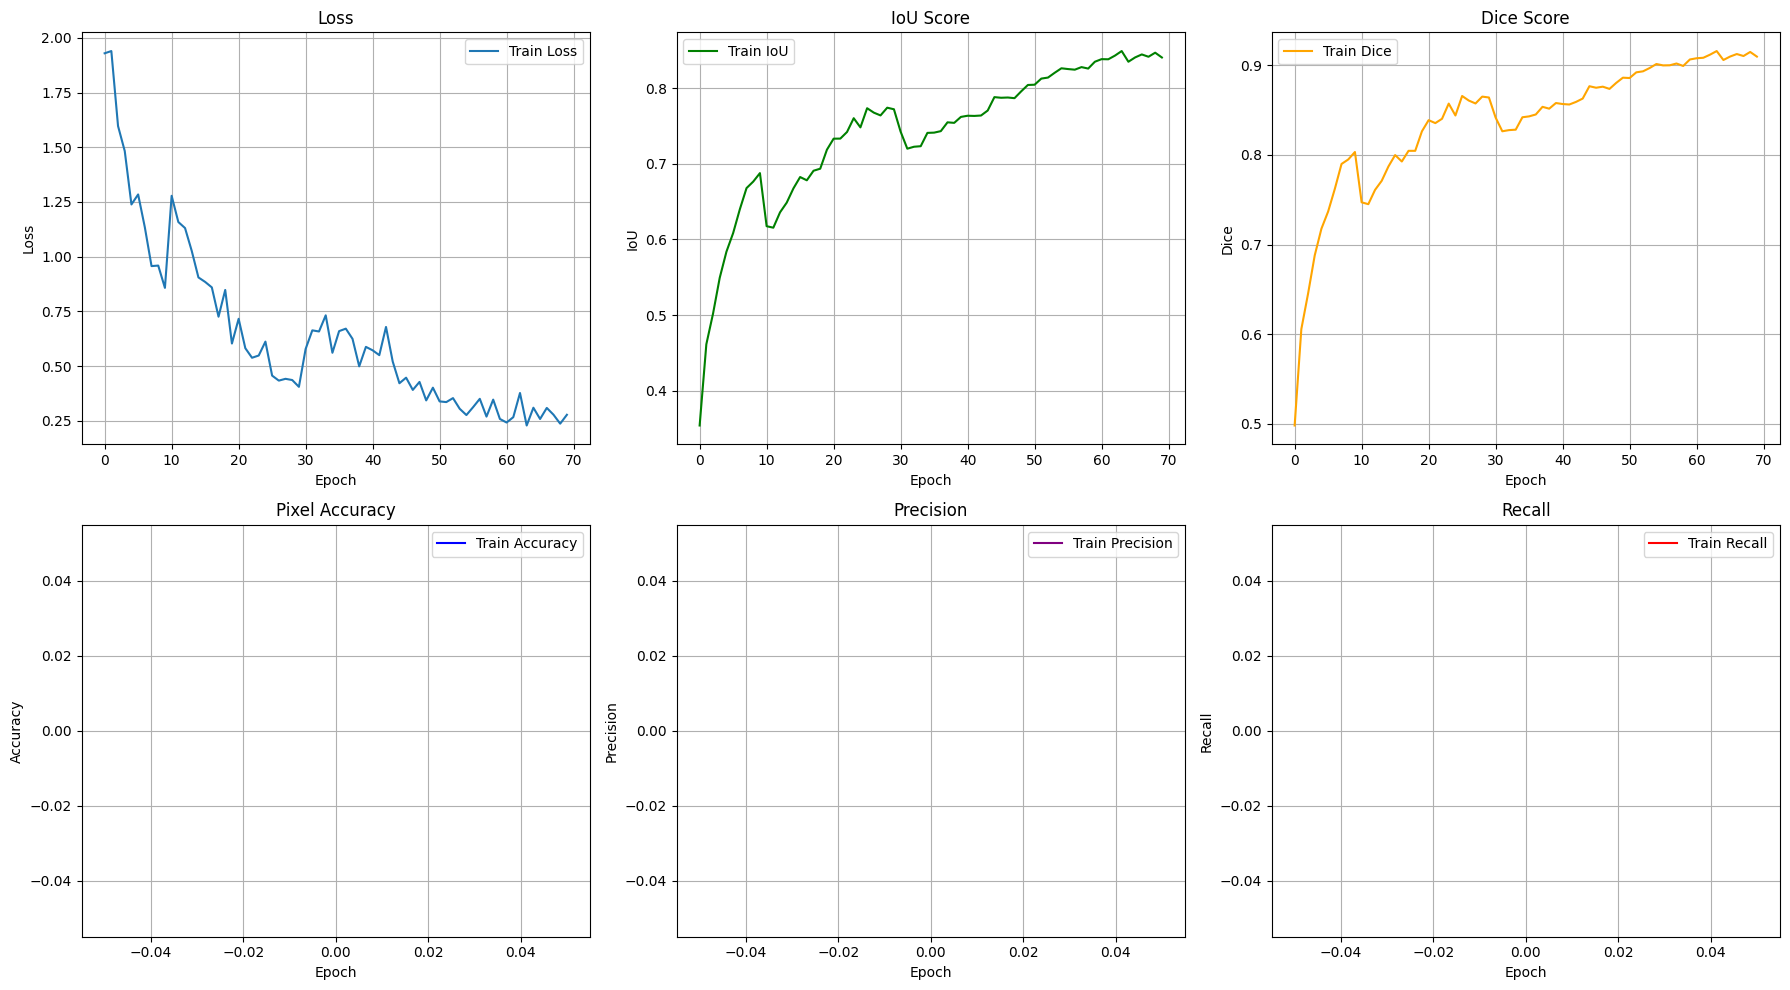

✅ Training history plotted and saved


In [28]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].set_title('Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# IoU
axes[0, 1].plot(history['train_iou'], label='Train IoU', color='green')
axes[0, 1].set_title('IoU Score')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('IoU')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Dice
axes[0, 2].plot(history['train_dice'], label='Train Dice', color='orange')
axes[0, 2].set_title('Dice Score')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Dice')
axes[0, 2].legend()
axes[0, 2].grid(True)

# Accuracy
axes[1, 0].plot(history['train_accuracy'], label='Train Accuracy', color='blue')
axes[1, 0].set_title('Pixel Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Precision
axes[1, 1].plot(history['train_precision'], label='Train Precision', color='purple')
axes[1, 1].set_title('Precision')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].legend()
axes[1, 1].grid(True)

# Recall
axes[1, 2].plot(history['train_recall'], label='Train Recall', color='red')
axes[1, 2].set_title('Recall')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Recall')
axes[1, 2].legend()
axes[1, 2].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Training history plotted and saved")

## Step 14: Evaluate Best Model

In [29]:
# Check a single batch to debug
model.eval()
imgs, masks = next(iter(train_loader))
imgs = imgs.to(DEVICE)
masks = masks.to(DEVICE)

with torch.no_grad():
    logits = model(imgs)
    probs = torch.sigmoid(logits)
    
    print("Model outputs:")
    print(f"Logits - min: {logits.min().item():.4f}, max: {logits.max().item():.4f}, mean: {logits.mean().item():.4f}")
    print(f"Probs  - min: {probs.min().item():.4f}, max: {probs.max().item():.4f}, mean: {probs.mean().item():.4f}")
    print(f"\nMask - min: {masks.min().item():.4f}, max: {masks.max().item():.4f}, unique values: {masks.unique()}")
    print(f"\nPrediction stats:")
    print(f"Pixels > 0.5: {(probs > 0.5).sum().item()} / {probs.numel()}")
    print(f"Positive mask pixels: {(masks > 0.5).sum().item()} / {masks.numel()}")

Model outputs:
Logits - min: -38.3618, max: 12.5216, mean: -4.5419
Probs  - min: 0.0000, max: 1.0000, mean: 0.4036

Mask - min: 0.0000, max: 1.0000, unique values: tensor([0., 1.], device='cuda:0')

Prediction stats:
Pixels > 0.5: 478610 / 1179648
Positive mask pixels: 450728 / 1179648


In [30]:
# Load best model
checkpoint = torch.load("best_deeplabv3plus.pth")
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("Best model loaded from checkpoint:")
print(f"Epoch: {checkpoint['epoch']}")
print(f"IoU: {checkpoint['iou']:.4f}")
print(f"Dice: {checkpoint['dice']:.4f}")

# Evaluate on training set
print("\nEvaluating on training set...")
total_iou = 0
total_dice = 0
total_acc = 0
total_precision = 0
total_recall = 0

with torch.no_grad():
    for imgs, masks in tqdm(train_loader, desc="Evaluating"):
        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE)
        
        preds = model(imgs)
        
        total_iou += calculate_iou(preds, masks, threshold=THRESHOLD)
        total_dice += calculate_dice(preds, masks, threshold=THRESHOLD)
        total_acc += calculate_pixel_accuracy(preds, masks, threshold=THRESHOLD)
        precision, recall = calculate_precision_recall(preds, masks, threshold=THRESHOLD)
        total_precision += precision
        total_recall += recall

n_batches = len(train_loader)
print(f"\n{'='*70}")
print(f"FINAL MODEL PERFORMANCE ON TRAINING SET")
print(f"{'='*70}")
print(f"Average IoU:       {total_iou/n_batches:.4f}")
print(f"Average Dice:      {total_dice/n_batches:.4f}")
print(f"Average Accuracy:  {total_acc/n_batches:.4f}")
print(f"Average Precision: {total_precision/n_batches:.4f}")
print(f"Average Recall:    {total_recall/n_batches:.4f}")
print(f"{'='*70}")

print("\n⚠️ KEY METRICS TO WATCH:")
print("  - IoU should be > 0.5 for good segmentation")
print("  - Dice should be > 0.6 for good segmentation")
print("  - If IoU/Dice are low but Accuracy is high, model is predicting too much background")

Best model loaded from checkpoint:
Epoch: 63
IoU: 0.8490
Dice: 0.9161

Evaluating on training set...


Evaluating: 100%|██████████| 249/249 [00:40<00:00,  6.09it/s]


FINAL MODEL PERFORMANCE ON TRAINING SET
Average IoU:       0.8418
Average Dice:      0.9108
Average Accuracy:  0.9773
Average Precision: 0.8563
Average Recall:    0.9791

⚠️ KEY METRICS TO WATCH:
  - IoU should be > 0.5 for good segmentation
  - Dice should be > 0.6 for good segmentation
  - If IoU/Dice are low but Accuracy is high, model is predicting too much background


## Step 15: Visualize Predictions on Training Data

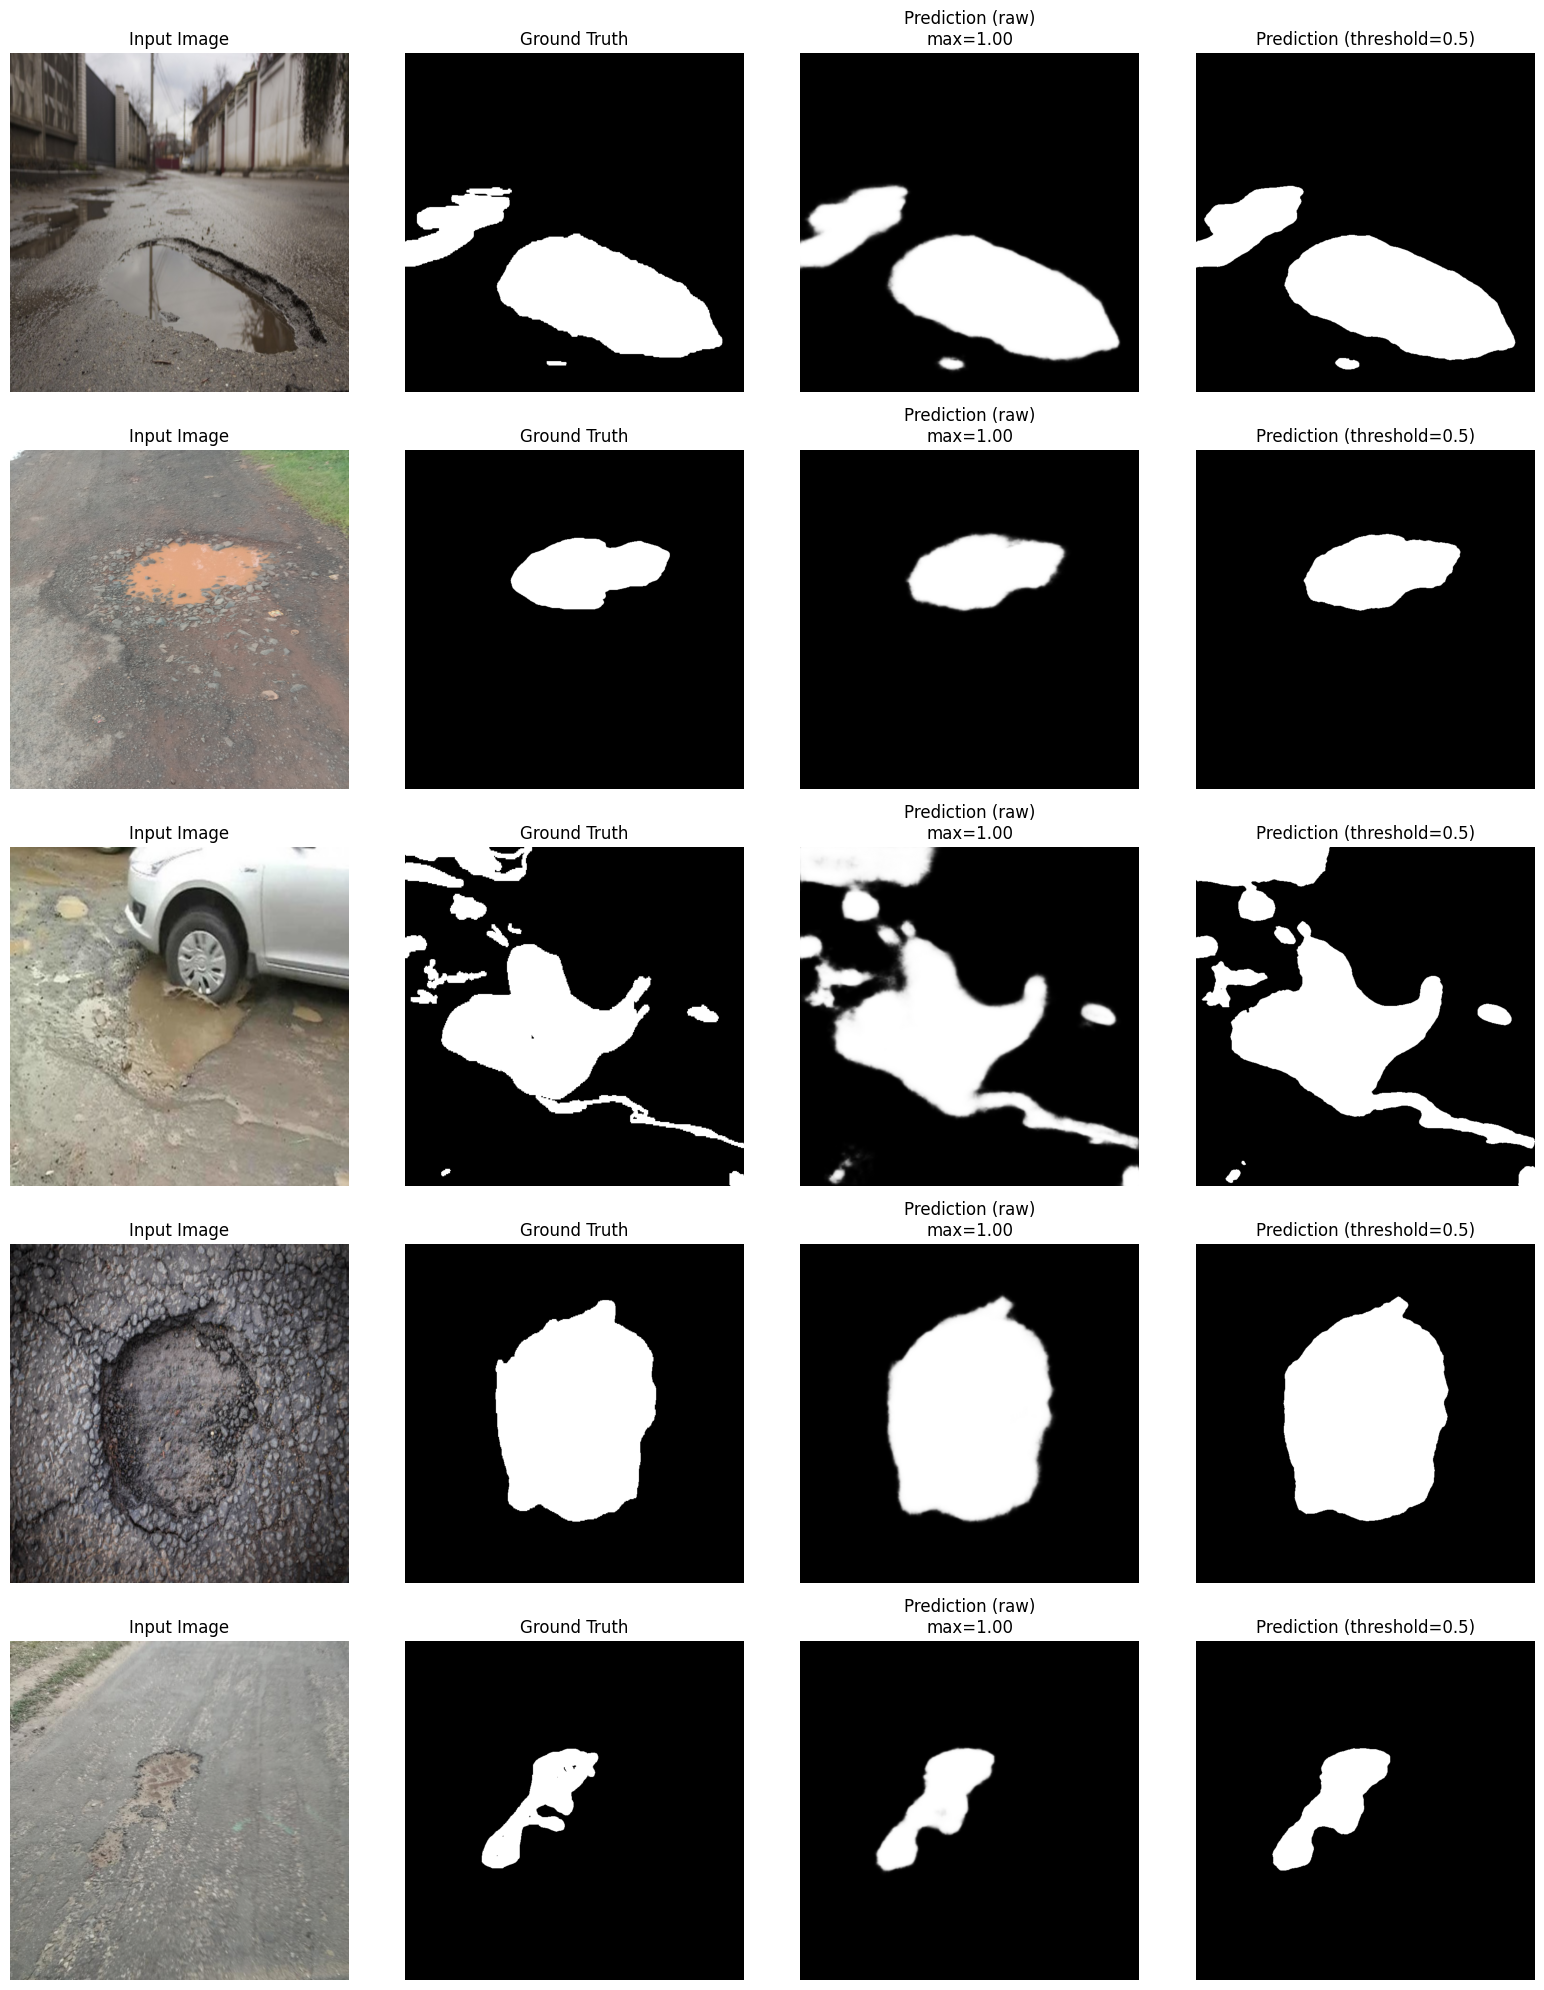


⚠️ CHECK: Predictions should match ground truth masks closely
⚠️ If predictions are all black or all white, the model needs more training or different hyperparameters


In [31]:
def visualize_predictions(model, dataset, n=5, threshold=0.5):
    """Visualize model predictions"""
    model.eval()
    fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))
    
    indices = np.random.choice(len(dataset), n, replace=False)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            img, mask = dataset[idx]
            
            # Get prediction
            pred = model(img.unsqueeze(0).to(DEVICE))
            pred = torch.sigmoid(pred)[0, 0].cpu().numpy()
            pred_binary = (pred > threshold).astype(np.uint8)
            
            # Convert to numpy
            img_np = img.permute(1, 2, 0).numpy()
            mask_np = mask.squeeze().numpy()
            
            # Plot
            axes[i, 0].imshow(img_np)
            axes[i, 0].set_title('Input Image')
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(mask_np, cmap='gray', vmin=0, vmax=1)
            axes[i, 1].set_title('Ground Truth')
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(pred, cmap='gray', vmin=0, vmax=1)
            axes[i, 2].set_title(f'Prediction (raw)\nmax={pred.max():.2f}')
            axes[i, 2].axis('off')
            
            axes[i, 3].imshow(pred_binary, cmap='gray', vmin=0, vmax=1)
            axes[i, 3].set_title(f'Prediction (threshold={threshold})')
            axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.savefig('predictions_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

# Visualize predictions
eval_dataset = SegDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, transform=val_transform)
visualize_predictions(model, eval_dataset, n=5, threshold=THRESHOLD)

print("\n⚠️ CHECK: Predictions should match ground truth masks closely")
print("⚠️ If predictions are all black or all white, the model needs more training or different hyperparameters")

## Step 16: RLE Encoding Function

In [32]:
def encode_rle(mask: np.ndarray, pos_value: int = 255) -> str:
    """Encode mask to RLE format for Kaggle submission"""
    binary = (mask == pos_value).astype(np.uint8)
    pixels = binary.T.flatten()
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[0::2]
    return " ".join(str(x) for x in runs)

print("✅ RLE encoding function defined")

✅ RLE encoding function defined


## Step 17: Generate Test Predictions and Submission

In [33]:
# Generate submission with the working model
model.eval()
rows = []

THRESHOLD = 0.5

print("Generating submission...")

for img_id in tqdm(test_imgs, desc="Processing test images"):
    img_path = os.path.join(TEST_IMG_DIR, img_id)
    img = read_rgb(img_path)
    
    H, W = img.shape[:2]
    
    # CRITICAL: Apply the SAME transform as training (which includes normalization)
    transformed = val_transform(image=img, mask=np.zeros((H, W), dtype=np.uint8))
    img_tensor = transformed['image']
    
    # CRITICAL: Ensure it's float and normalized
    if img_tensor.dtype == torch.uint8:
        img_tensor = img_tensor.float() / 255.0
    
    # Add batch dimension and move to device
    img_tensor = img_tensor.unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        pred = model(img_tensor)
        pred = torch.sigmoid(pred)[0, 0].cpu().numpy()
    
    # Resize back to original size
    pred_resized = cv2.resize(pred, (W, H), interpolation=cv2.INTER_LINEAR)
    
    # Apply threshold
    pred_mask = (pred_resized > THRESHOLD).astype(np.uint8) * 255
    
    # Encode to RLE
    rle = encode_rle(pred_mask, pos_value=255)
    rows.append({"ImageId": img_id, "rle": rle})

submission = pd.DataFrame(rows, columns=["ImageId", "rle"])
submission.to_csv("submission_epoch6.csv", index=False)

print(f"\n✅ submission_epoch2.csv saved with {len(submission)} predictions")

Generating submission...


Processing test images: 100%|██████████| 295/295 [00:28<00:00, 10.30it/s]



✅ submission_epoch2.csv saved with 295 predictions


## Step 18: Visualize Test Predictions (Sample)

RuntimeError: Input type (torch.cuda.ByteTensor) and weight type (torch.cuda.FloatTensor) should be the same

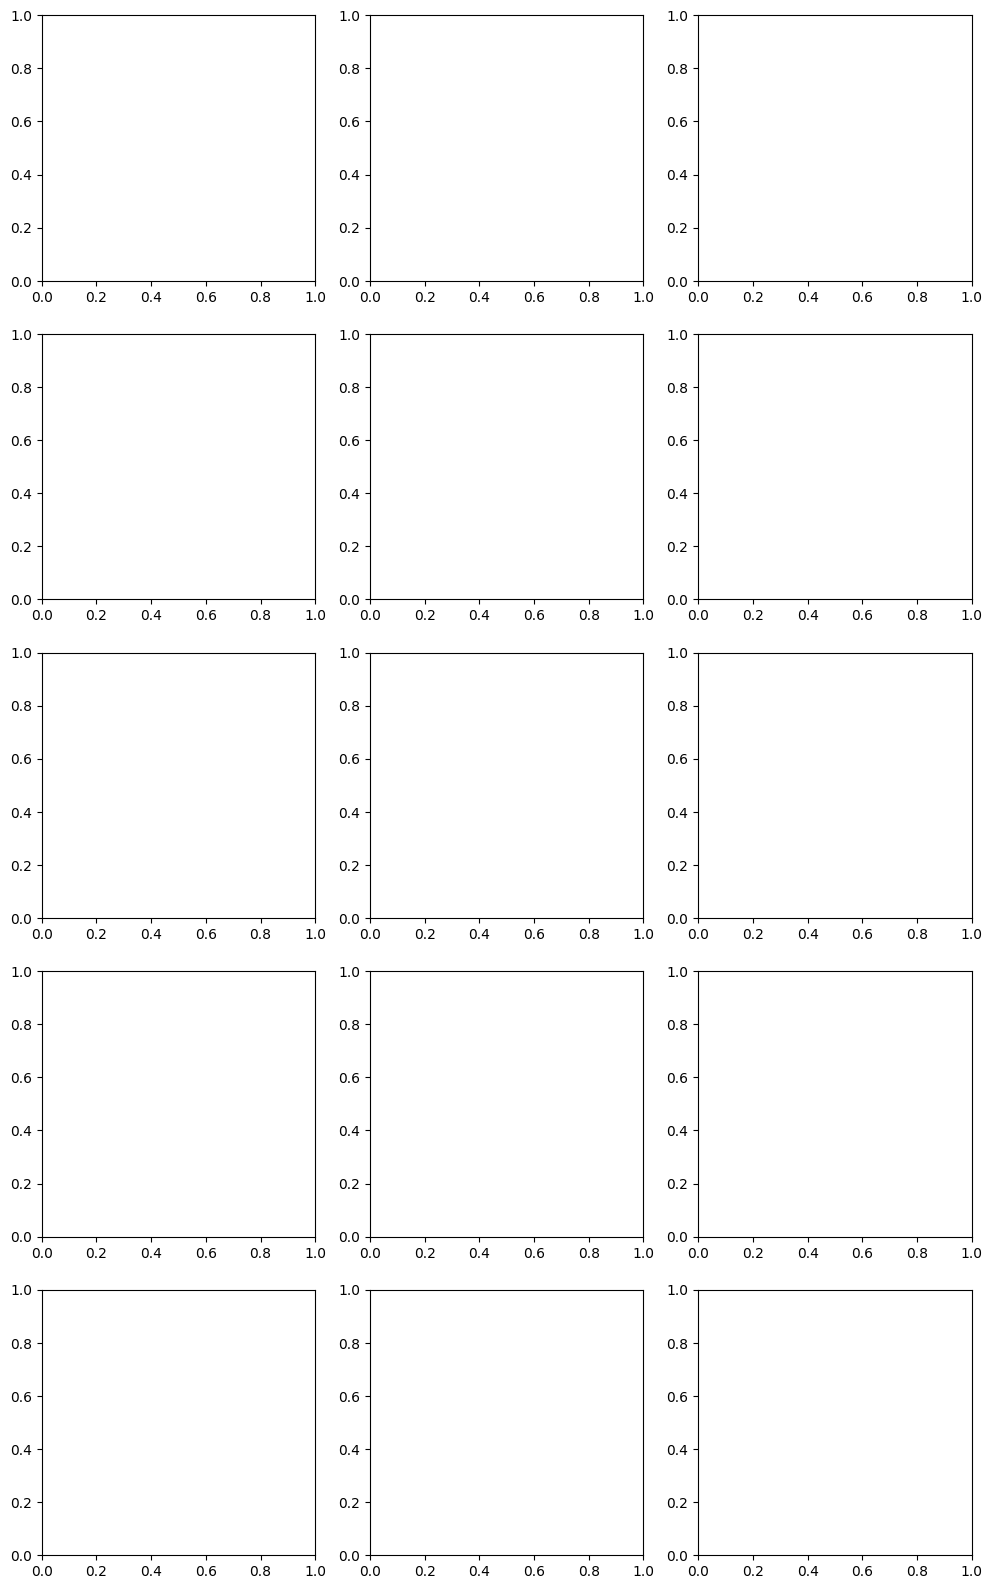

In [31]:
def visualize_test_predictions(n=5):
    """Visualize predictions on test images"""
    model.eval()
    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    
    sample_imgs = np.random.choice(test_imgs, n, replace=False)
    
    with torch.no_grad():
        for i, img_id in enumerate(sample_imgs):
            # Read image
            img_path = os.path.join(TEST_IMG_DIR, img_id)
            img = read_rgb(img_path)
            H, W = img.shape[:2]
            
            # Transform and predict
            transformed = val_transform(image=img, mask=np.zeros((H, W), dtype=np.uint8))
            img_tensor = transformed['image'].unsqueeze(0).to(DEVICE)
            
            pred = model(img_tensor)
            pred = torch.sigmoid(pred)[0, 0].cpu().numpy()
            
            # Resize back
            pred_resized = cv2.resize(pred, (W, H), interpolation=cv2.INTER_LINEAR)
            pred_binary = (pred_resized > THRESHOLD).astype(np.uint8)
            
            # Plot
            axes[i, 0].imshow(img)
            axes[i, 0].set_title(f'Test Image: {img_id}')
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(pred_resized, cmap='gray', vmin=0, vmax=1)
            axes[i, 1].set_title(f'Prediction (raw)\nmax={pred_resized.max():.2f}')
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(img)
            axes[i, 2].imshow(pred_binary, cmap='Reds', alpha=0.5, vmin=0, vmax=1)
            axes[i, 2].set_title('Overlay')
            axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig('test_predictions_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_test_predictions(n=5)

print("\n⚠️ VISUAL CHECK: Do the predictions look reasonable?")
print("If predictions are too sparse or too dense, consider adjusting the THRESHOLD value")

## Step 19: Summary and Next Steps

In [23]:
print("="*70)
print("TRAINING COMPLETE - SUMMARY")
print("="*70)
print(f"\nModel: UNet++ with EfficientNet-B2 encoder")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs Trained: {EPOCHS}")
print(f"Learning Rate: {LR}")
print(f"Prediction Threshold: {THRESHOLD}")

print(f"\nBest Model Performance:")
print(f"  - IoU: {checkpoint['iou']:.4f}")
print(f"  - Dice: {checkpoint['dice']:.4f}")

print(f"\nFiles Generated:")
print(f"  - best_model.pth (saved model checkpoint)")
print(f"  - submission.csv (Kaggle submission file)")
print(f"  - training_history.png (training metrics plot)")
print(f"  - predictions_visualization.png (training predictions)")
print(f"  - test_predictions_visualization.png (test predictions)")

print(f"\n" + "="*70)
print("NEXT STEPS:")
print("="*70)
print("1. Check the visualization images to verify predictions look correct")
print("2. If IoU < 0.5 or Dice < 0.6:")
print("   - Increase EPOCHS (try 100)")
print("   - Adjust Focal Loss alpha (increase for more foreground focus)")
print("   - Try different threshold values (0.3-0.7)")
print("3. If predictions look good, submit submission.csv to Kaggle")
print("4. Monitor Kaggle score - if low:")
print("   - Verify mask reading is correct (check visualizations)")
print("   - Ensure test preprocessing matches training")
print("   - Consider TTA (Test Time Augmentation)")
print("="*70)

TRAINING COMPLETE - SUMMARY

Model: UNet++ with EfficientNet-B2 encoder
Image Size: 768x768
Batch Size: 1
Epochs Trained: 50
Learning Rate: 0.0003
Prediction Threshold: 0.5

Best Model Performance:
  - IoU: 0.6854
  - Dice: 0.7974

Files Generated:
  - best_model.pth (saved model checkpoint)
  - submission.csv (Kaggle submission file)
  - training_history.png (training metrics plot)
  - predictions_visualization.png (training predictions)
  - test_predictions_visualization.png (test predictions)

NEXT STEPS:
1. Check the visualization images to verify predictions look correct
2. If IoU < 0.5 or Dice < 0.6:
   - Increase EPOCHS (try 100)
   - Adjust Focal Loss alpha (increase for more foreground focus)
   - Try different threshold values (0.3-0.7)
3. If predictions look good, submit submission.csv to Kaggle
4. Monitor Kaggle score - if low:
   - Verify mask reading is correct (check visualizations)
   - Ensure test preprocessing matches training
   - Consider TTA (Test Time Augmentation